In [ ]:
from src.utils import get_data_env
from src.dataloading import EpiConfig, DataOrchestrator, GraphDataLoaderManager, ShallowDataLoaderManager
from src.models import PersistenceModel, NodeRFModel, NodeLSTMModel, GATv2Model, ClimateologyModel, SpatialGNNModel
from src.evaluation import Evaluator

disease_name    = 'influenza'
nuts_level      = 'nuts3'
min_date        = '2006-05-15'
max_date        = '2020-06-01'
split_trainval  = '2018-06-01'
split_valtest   = '2019-06-01'
split_berlin    = False

horizon_size    = 2
horizon_leadtime= 3
sequence_length = 1
lags            = 1

horizon_size    = 4
horizon_leadtime= 1
sequence_length = 1
lag_num         = 1

config = EpiConfig(
    disease             = 'influenza',
    data_env_dir        = get_data_env(),
    date_range          = (min_date, max_date),
    horizon_size        = horizon_size,
    sequence_length     = sequence_length,
    horizon_leadtime    = horizon_leadtime,
    lag_num             = lag_num,
    nuts_level          = nuts_level,
    log_transform       = ['incidence'],
    split_berlin        = split_berlin,
    include_population  = False,
    split_trainval      = split_trainval, 
    split_valtest       = split_valtest,
    target_column       = 'incidence',
    lag_column          = 'incidence',    
    )       
data_orchestrator = DataOrchestrator(config).build()

target: incidence


In [16]:
n_epochs        = 250
lr              = 0.0001
min_delta       = 0.0001
loss            = 'mse'

global_hparams = {
    "lr"                : lr,
    "n_epochs"          : n_epochs,
    "scheduler"         : 'plateau',
    "scheduler_kwargs"  :  {'mode': 'min', 'factor': 0.5, 'patience': 6},
    'min_delta'         : min_delta,
    'loss'              : loss,
    'patience'          : 20,
    }

shallowdata        = ShallowDataLoaderManager(data_orchestrator).construct_dataloaders()
graphdataloader_id  = GraphDataLoaderManager(data_orchestrator).retrieve_graph('identity_graph').construct_dataloaders()
graphdataloader_bn  = GraphDataLoaderManager(data_orchestrator).retrieve_graph('boolean_neighbors_self').construct_dataloaders()
graphdataloader_gr1 = GraphDataLoaderManager(data_orchestrator).retrieve_graph('gravity1').construct_dataloaders()
graphdataloader_cm1 = GraphDataLoaderManager(data_orchestrator).retrieve_graph('commuter1').construct_dataloaders()
graphdataloader_gr2 = GraphDataLoaderManager(data_orchestrator).retrieve_graph('gravity4').construct_dataloaders()
graphdataloader_cm2 = GraphDataLoaderManager(data_orchestrator).retrieve_graph('commuter4').construct_dataloaders()


In [17]:
persistence = PersistenceModel(shallowdata)
persistence.forecast('test')

climateology = ClimateologyModel(shallowdata)
climateology.forecast('test')

ClimateologyModel(name='Climateology Model')

## RF

In [18]:
rf = NodeRFModel(shallowdata)
rf.set_global_hparams()
rf.set_model_hparams(n_estimators=100)
rf.train(verbose=2)
rf.forecast('test')

Training loss for horizon 0: RMSE = 0.4290, MAE = 0.1690
Validation loss for horizon 0: RMSE = 0.5623, MAE = 0.2522
Training loss for horizon 1: RMSE = 0.5343, MAE = 0.2108
Validation loss for horizon 1: RMSE = 0.7113, MAE = 0.3157
Training loss for horizon 2: RMSE = 0.6200, MAE = 0.2463
Validation loss for horizon 2: RMSE = 0.8373, MAE = 0.3672
Training loss for horizon 3: RMSE = 0.6927, MAE = 0.2795
Validation loss for horizon 3: RMSE = 0.9615, MAE = 0.4173


NodeRFModel(name='NodeRFModel')

## LSTM


==                     lstm                     ==
Dataloader Snapshot: GraphData(x=(400, 3, 1), y=(400, 4), edge_index=(2, 400), edge_weight=(400,))


Training epochs:  26%|███████████████████████████████████████████▏                                                                                                                          | 65/250 [02:35<07:21,  2.39s/it]


Early stopping: Validation loss hasn't improved for 20 epochs
Restored model from best validation loss: 0.4388


Forecasting test: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 47/47 [00:00<00:00, 574.68it/s]

Test loss: 0.6799


(<Figure size 1600x700 with 1 Axes>,
 [<Axes: title={'center': 'Region Hannover [node: 26]'}, ylabel='target'>])

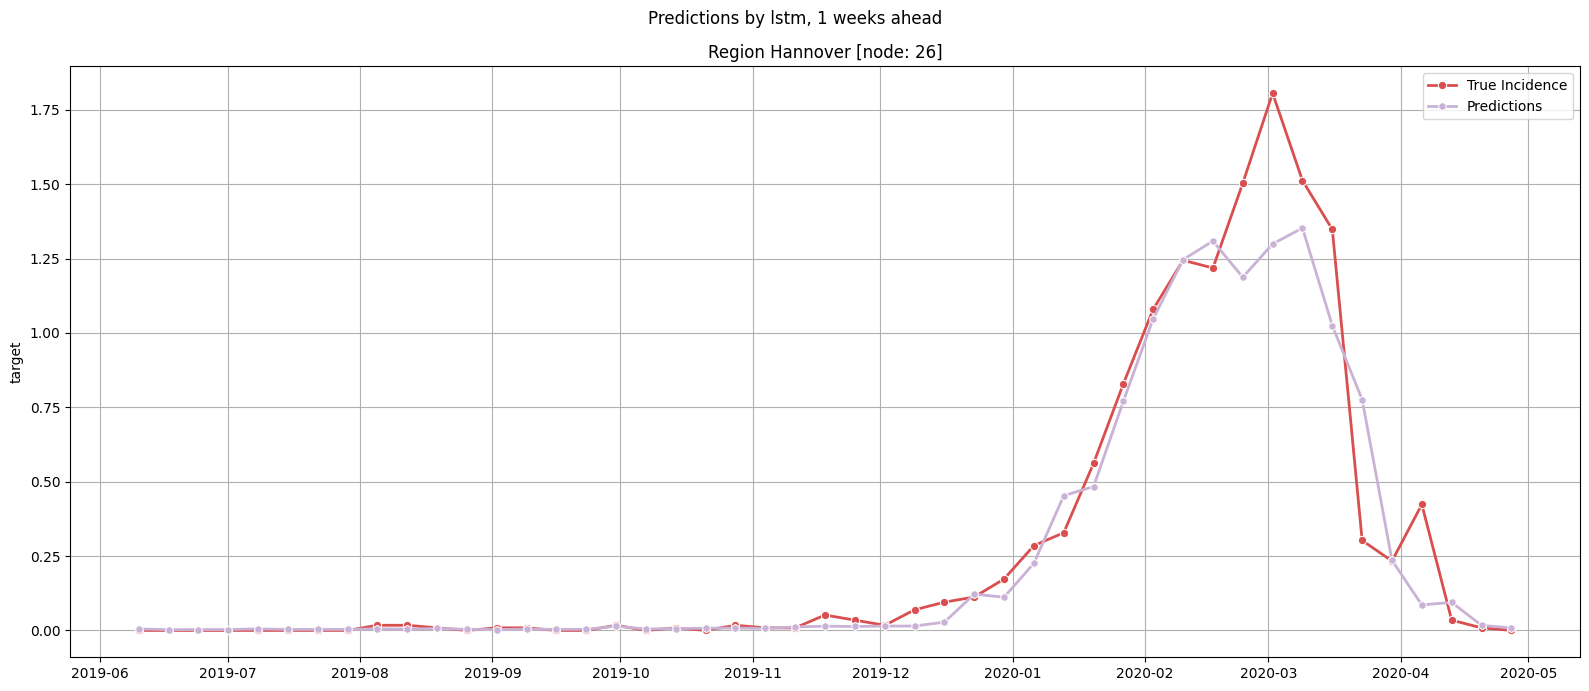

In [19]:
lstm = NodeLSTMModel(graphdataloader_id, name = 'lstm')
lstm.set_model_hparams(hidden_size=128)
lstm.set_global_hparams(**global_hparams)
lstm.train(verbose = 0, show_loss=False)
lstm.forecast('test')
lstm.show_forecasts(26)

## GNNs

In [ ]:
spatial_model1 = SpatialGNNModel(graphdataloader_id, name = 'gcn-identity_graph')
spatial_model1.set_model_hparams()
spatial_model1.set_global_hparams(**global_hparams)
spatial_model1.train(verbose = 0, show_loss=False)
spatial_model1.forecast('test')
spatial_model1.show_forecasts(26)

spatial_model2 = SpatialGNNModel(graphdataloader_bn, name = 'gcn-boolean_neighbors')
spatial_model2.set_model_hparams()
spatial_model2.set_global_hparams(**global_hparams)
spatial_model2.train(verbose = 0, show_loss=False)
spatial_model2.forecast('test')
spatial_model2.show_forecasts(26)


spatiotemporal_model1 = GATv2Model(graphdataloader_id, name = 'gatv2-identity_graph')
spatiotemporal_model1.set_model_hparams()
spatiotemporal_model1.set_global_hparams(**global_hparams)
spatiotemporal_model1.train(verbose = 0, show_loss=False)
spatiotemporal_model1.forecast('test')
spatiotemporal_model1.show_forecasts(26)

spatiotemporal_model2 = GATv2Model(graphdataloader_bn, name = 'gatv2-boolean neighbors')
spatiotemporal_model2.set_model_hparams()
spatiotemporal_model2.set_global_hparams(**global_hparams)
spatiotemporal_model2.train(verbose = 0, show_loss=False)
spatiotemporal_model2.forecast('test')
spatiotemporal_model2.show_forecasts(26)



==              gcn-identity_graph              ==
Dataloader Snapshot: GraphData(x=(400, 3, 1), y=(400, 4), edge_index=(2, 400), edge_weight=(400,))


Training epochs:   0%|                                                                                                                                                                               | 0/250 [00:00<?, ?it/s]

Training epochs:  28%|█████████████████████████████████████████████▊                                                                                                                        | 69/250 [02:00<05:14,  1.74s/it]

In [ ]:
evaluation = Evaluator([persistence, climateology, spatial_model1, spatial_model2, lstm, spatiotemporal_model1, spatiotemporal_model2])
evaluation.add_evaluation(0, 'test')


computing metrics: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:06<00:00,  1.12s/it]


/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:130: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:130: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:130: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplott

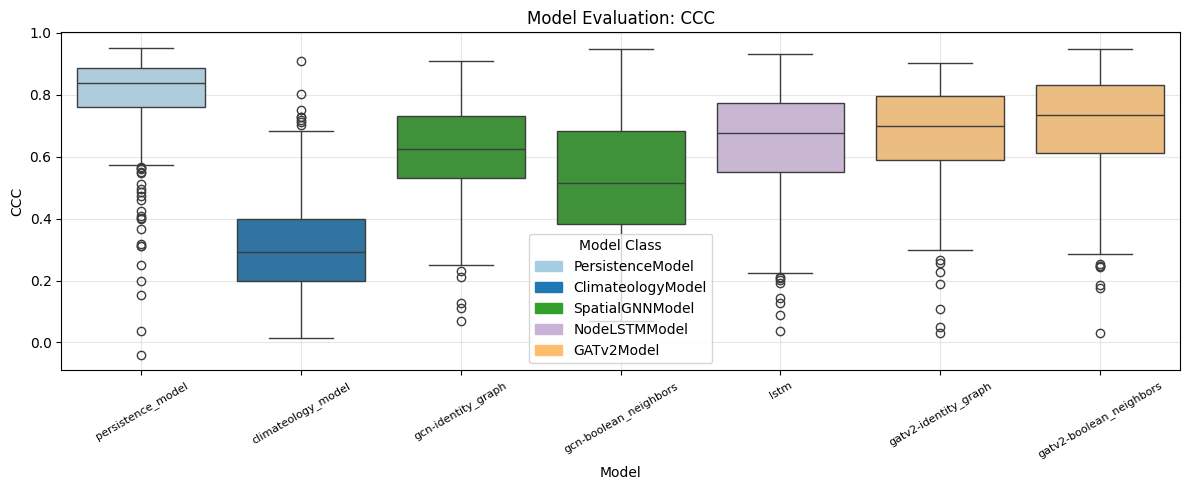

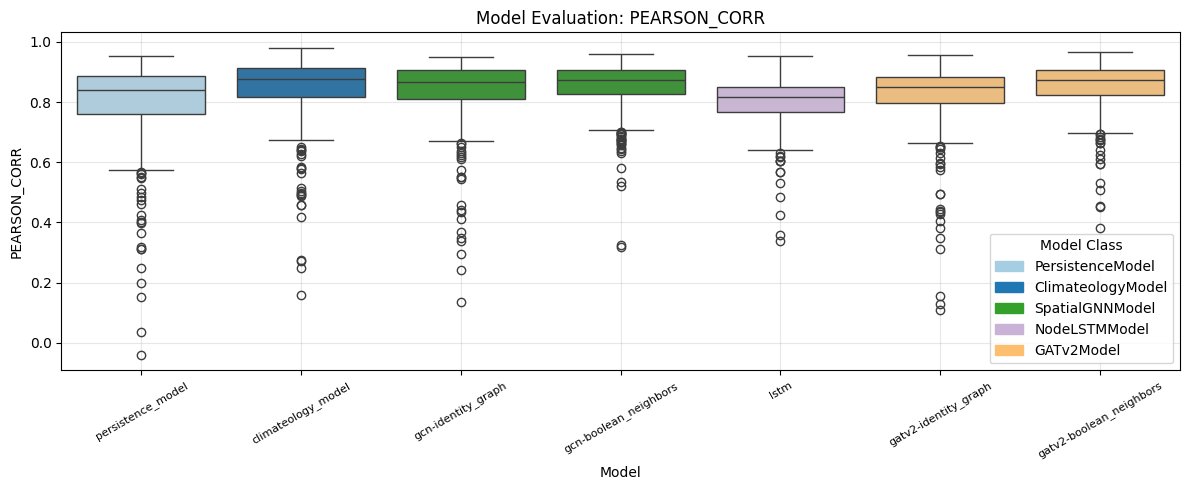

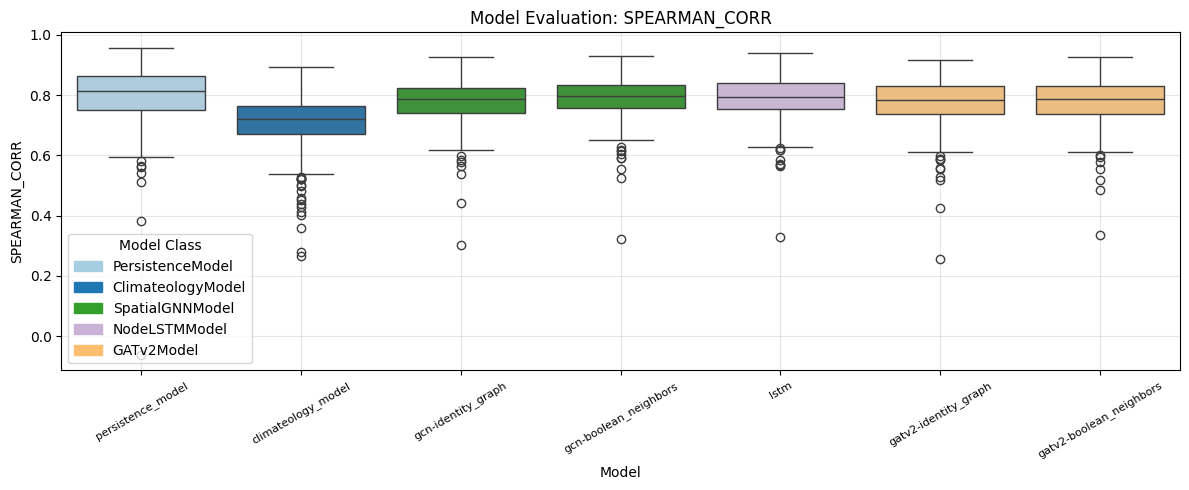

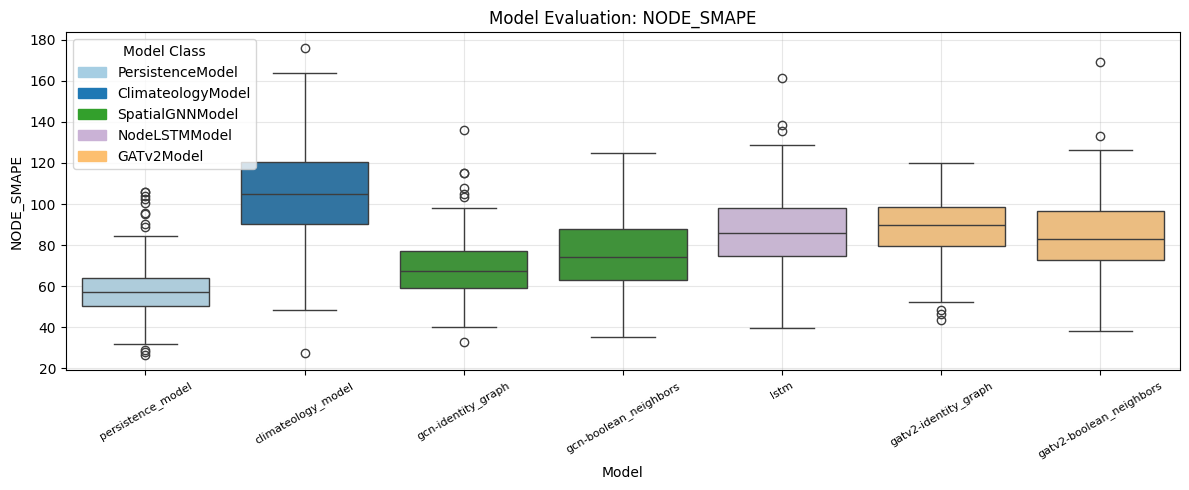

In [ ]:
evaluation.plotter.plot_metric('ccc', horizon = 'horizon_0', plot_type='box')
evaluation.plotter.plot_metric('pearson_corr', horizon = 'horizon_0', plot_type='box')
evaluation.plotter.plot_metric('spearman_corr', horizon = 'horizon_0', plot_type='box')
evaluation.plotter.plot_metric('node_smape', horizon = 'horizon_0', plot_type='box')